In [ ]:
!pip install pymupdf pandas
import os
import re
import fitz  # PyMuPDF
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 60.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/carbon_dataset_pymupdf.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(165941, 3)


,file_name,chunk_id,text
0,2023-cdp-climate-change-report (1).pdf,0,lockheed martin corporation - climate change 2...
1,2023-cdp-climate-change-report (1).pdf,1,fire control systems; mission operations suppo...
2,2023-cdp-climate-change-report (1).pdf,2,if you are providing emissions data for past r...
3,2023-cdp-climate-change-report (1).pdf,3,for your organization provide your unique iden...
4,2023-cdp-climate-change-report (1).pdf,4,against our climate goals and performance. thi...


In [ ]:
import re

def clean_text(text):
    text = str(text)

    # remove bullets and weird symbols
    text = re.sub(r'[•▪●]', ' ', text)

    # remove section codes like 302-2
    text = re.sub(r'\b\d{3}-\d\b', '', text)

    # remove standalone numbers (optional)
    text = re.sub(r'\b\d{1,3}(,\d{3})*\b', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
def is_table_like(text):
    text = str(text) # Convert text to string to handle floats (NaNs)
    numbers = len(re.findall(r'\d', text))
    words = len(text.split())
    return numbers > words  # more numbers than words = table

df = df[~df['text'].apply(is_table_like)]

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df

,file_name,chunk_id,text,clean_text
0,2023-cdp-climate-change-report (1).pdf,0,lockheed martin corporation - climate change 2...,lockheed martin corporation - climate change 2...
1,2023-cdp-climate-change-report (1).pdf,1,fire control systems; mission operations suppo...,fire control systems; mission operations suppo...
2,2023-cdp-climate-change-report (1).pdf,2,if you are providing emissions data for past r...,if you are providing emissions data for past r...
3,2023-cdp-climate-change-report (1).pdf,3,for your organization provide your unique iden...,for your organization provide your unique iden...
4,2023-cdp-climate-change-report (1).pdf,4,against our climate goals and performance. thi...,against our climate goals and performance. thi...
...,...,...,...,...
165936,2022-Essex-ESG-Report-24.pdf,51,tcfd disclosure 2022 disclosure metrics and ta...,tcfd disclosure 2022 disclosure metrics and ta...
165937,2022-Essex-ESG-Report-24.pdf,52,report scope 3 emissions across our entire por...,report scope emissions across our entire portf...
165938,2024_Essex_Sustainability_and_Impact_Report.pdf,123,about us transparent business practices sustai...,about us transparent business practices sustai...
165939,2024_Essex_Sustainability_and_Impact_Report.pdf,124,about us transparent business practices sustai...,about us transparent business practices sustai...


In [ ]:
df.tail()

,file_name,chunk_id,text,clean_text
165936,2022-Essex-ESG-Report-24.pdf,51,tcfd disclosure 2022 disclosure metrics and ta...,tcfd disclosure 2022 disclosure metrics and ta...
165937,2022-Essex-ESG-Report-24.pdf,52,report scope 3 emissions across our entire por...,report scope emissions across our entire portf...
165938,2024_Essex_Sustainability_and_Impact_Report.pdf,123,about us transparent business practices sustai...,about us transparent business practices sustai...
165939,2024_Essex_Sustainability_and_Impact_Report.pdf,124,about us transparent business practices sustai...,about us transparent business practices sustai...
165940,2022-Essex-ESG-Report-24.pdf,53,assurance statement we commissioned lloyd’s re...,assurance statement we commissioned lloyd’s re...


In [ ]:
!pip install transformers torch tqdm pandas

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
model_name = "climatebert/distilroberta-base-climate-detector"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50500, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [ ]:
df = df.dropna(subset=['text']).reset_index(drop=True)
df

,file_name,chunk_id,text,clean_text
0,2023-cdp-climate-change-report (1).pdf,0,lockheed martin corporation - climate change 2...,lockheed martin corporation - climate change 2...
1,2023-cdp-climate-change-report (1).pdf,1,fire control systems; mission operations suppo...,fire control systems; mission operations suppo...
2,2023-cdp-climate-change-report (1).pdf,2,if you are providing emissions data for past r...,if you are providing emissions data for past r...
3,2023-cdp-climate-change-report (1).pdf,3,for your organization provide your unique iden...,for your organization provide your unique iden...
4,2023-cdp-climate-change-report (1).pdf,4,against our climate goals and performance. thi...,against our climate goals and performance. thi...
...,...,...,...,...
162089,2022-Essex-ESG-Report-24.pdf,51,tcfd disclosure 2022 disclosure metrics and ta...,tcfd disclosure 2022 disclosure metrics and ta...
162090,2022-Essex-ESG-Report-24.pdf,52,report scope 3 emissions across our entire por...,report scope emissions across our entire portf...
162091,2024_Essex_Sustainability_and_Impact_Report.pdf,123,about us transparent business practices sustai...,about us transparent business practices sustai...
162092,2024_Essex_Sustainability_and_Impact_Report.pdf,124,about us transparent business practices sustai...,about us transparent business practices sustai...


In [ ]:
import torch.nn.functional as F
from tqdm import tqdm
import os
import pandas as pd

SAVE_PATH = "/content/climate_output.csv"

def batch_predict_with_save(df, batch_size=16):  # 🔥 increased batch size
    start = 0

    # Resume logic
    if os.path.exists(SAVE_PATH):
        temp = pd.read_csv(SAVE_PATH)
        start = len(temp)
        print(f"✅ Resuming from row {start}")
    else:
        print("🚀 Starting fresh")

    for i in tqdm(range(start, len(df), batch_size)):
        batch_df = df.iloc[i:i+batch_size]
        batch = batch_df['clean_text'].tolist()

        # Tokenization
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256   # 🔥 reduced from 512
        ).to(device)

        # Inference
        with torch.no_grad():
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=1)

        batch_scores = probs[:, 1].cpu().numpy()

        # Create batch result
        out_df = batch_df.copy()
        out_df['climate_score'] = batch_scores

        # ✅ Append ONLY this batch (FAST)
        if os.path.exists(SAVE_PATH):
            out_df.to_csv(SAVE_PATH, mode="a", header=False, index=False)
        else:
            out_df.to_csv(SAVE_PATH, index=False)

    print("🎉 Done!")

In [ ]:
batch_predict_with_save(df, batch_size=16)

🚀 Starting fresh


100%|██████████| 10131/10131 [22:47<00:00,  7.41it/s]

🎉 Done!


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import shutil

shutil.copy(
    "/content/climate_output.csv",
    "/content/drive/MyDrive/climate_output.csv"
)


'/content/drive/MyDrive/climate_output.csv'

In [ ]:
df_climate = pd.read_csv('/content/drive/MyDrive/climate_output.csv', on_bad_lines='skip')
df_climate['year'] = df_climate['file_name'].str.extract(r'(20\d{2})')

# Convert safely
df_climate['year'] = pd.to_numeric(df_climate['year'], errors='coerce')

# Drop bad rows
df_climate = df_climate.dropna(subset=['year'])

# Convert to int
df_climate['year'] = df_climate['year'].astype(int)

/tmp/ipykernel_437/920302249.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_climate = pd.read_csv('/content/drive/MyDrive/climate_output.csv', on_bad_lines='skip')


In [ ]:
df_climate

,file_name,chunk_id,text,clean_text,climate_score,year
0,2023-cdp-climate-change-report (1).pdf,0,lockheed martin corporation - climate change 2...,lockheed martin corporation - climate change 2...,0.996880,2023
1,2023-cdp-climate-change-report (1).pdf,1,fire control systems; mission operations suppo...,fire control systems; mission operations suppo...,0.842735,2023
2,2023-cdp-climate-change-report (1).pdf,2,if you are providing emissions data for past r...,if you are providing emissions data for past r...,0.998212,2023
3,2023-cdp-climate-change-report (1).pdf,3,for your organization provide your unique iden...,for your organization provide your unique iden...,0.998294,2023
4,2023-cdp-climate-change-report (1).pdf,4,against our climate goals and performance. thi...,against our climate goals and performance. thi...,0.998340,2023
...,...,...,...,...,...,...
162089,2022-Essex-ESG-Report-24.pdf,51,tcfd disclosure 2022 disclosure metrics and ta...,tcfd disclosure 2022 disclosure metrics and ta...,0.998316,2022
162090,2022-Essex-ESG-Report-24.pdf,52,report scope 3 emissions across our entire por...,report scope emissions across our entire portf...,0.998140,2022
162091,2024_Essex_Sustainability_and_Impact_Report.pdf,123,about us transparent business practices sustai...,about us transparent business practices sustai...,0.991948,2024
162092,2024_Essex_Sustainability_and_Impact_Report.pdf,124,about us transparent business practices sustai...,about us transparent business practices sustai...,0.991948,2024


In [ ]:
climate_yearly = df_climate.groupby("year")["climate_score"].mean().reset_index()

In [ ]:
import pandas as pd
import numpy as np
import re

# =====================================================
# LOAD CLIMATE DATASET
# =====================================================

df = pd.read_csv(
    "/content/drive/MyDrive/climate_output.csv",
    low_memory=False,
    on_bad_lines="skip"
)

print(f"Initial rows: {len(df):,}")

# =====================================================
# REMOVE DUPLICATES
# =====================================================

df = df.drop_duplicates(
    subset=["file_name", "chunk_id", "clean_text"]
).reset_index(drop=True)

# =====================================================
# REMOVE MISSING VALUES
# =====================================================

df = df.dropna(
    subset=["clean_text", "climate_score"]
).reset_index(drop=True)

df["clean_text"] = df["clean_text"].astype(str)

print(f"Rows after cleaning: {len(df):,}")

# =====================================================
# EXTRACT REPORTING YEAR
# =====================================================

def extract_year(filename):

    filename = str(filename)

    # Find all 4-digit years
    years = re.findall(r"20\d{2}", filename)

    if not years:
        return np.nan

    # Convert to integers
    years = [int(y) for y in years]

    # Keep only realistic report years
    valid_years = [y for y in years if 2018 <= y <= 2026]

    if not valid_years:
        return np.nan

    # Return the earliest valid year in the filename
    return min(valid_years)

df["year"] = df["file_name"].apply(extract_year)

print("Missing years:", df["year"].isna().sum())

df = df.dropna(subset=["year"]).copy()

df["year"] = df["year"].astype(int)

print("Years found:", sorted(df["year"].unique()))

# =====================================================
# EXTRACT COMPANY NAME
# =====================================================

def extract_company(filename):

    filename = str(filename)

    # Remove extension
    filename = re.sub(r"\.pdf$", "", filename, flags=re.IGNORECASE)

    # Remove year
    filename = re.sub(r"20\d{2}", " ", filename)

    # Remove common report words
    remove_words = [
        "sustainability",
        "report",
        "annual",
        "esg",
        "integrated",
        "climate",
        "change",
        "impact",
        "tcfd",
        "csr",
        "environmental",
        "social",
        "governance"
    ]

    name = filename.lower()

    for word in remove_words:
        name = name.replace(word, " ")

    # Replace separators
    name = re.sub(r"[_\-()]", " ", name)

    # Remove multiple spaces
    name = re.sub(r"\s+", " ", name).strip()

    return name.title()

df["company"] = df["file_name"].apply(extract_company)

# =====================================================
# CHUNK LENGTH
# =====================================================

df["word_count"] = (
    df["clean_text"]
      .str.split()
      .apply(len)
)

# =====================================================
# CREATE UNIQUE REPORT ID
# =====================================================

df["report_id"] = (
    df["company"]
    + "_"
    + df["year"].astype(str)
)

# =====================================================
# SORT DATASET
# =====================================================

df = df.sort_values(
    ["year", "company", "chunk_id"]
).reset_index(drop=True)

# =====================================================
# SUMMARY
# =====================================================

print("\n========== DATASET SUMMARY ==========")
print("Rows                :", len(df))
print("Companies           :", df["company"].nunique())
print("Reports             :", df["report_id"].nunique())
print("Years               :", sorted(df["year"].unique()))
print("Average ClimateBERT :", round(df["climate_score"].mean(), 4))
print("Average Words/Chunk :", round(df["word_count"].mean(), 2))

# =====================================================
# SAVE
# =====================================================

SAVE_PATH = "/content/drive/MyDrive/01_climate_master.csv"

df.to_csv(
    SAVE_PATH,
    index=False
)

print("\nMaster dataset saved successfully!")
print(SAVE_PATH)

# Preview
df.head()

Initial rows: 162,094
Rows after cleaning: 162,091
Missing years: 15621
Years found: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

========== DATASET SUMMARY ==========
Rows                : 146470
Companies           : 1003
Reports             : 1431
Years               : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Average ClimateBERT : 0.8985
Average Words/Chunk : 190.14

Master dataset saved successfully!
/content/drive/MyDrive/01_climate_master.csv


,file_name,chunk_id,text,clean_text,climate_score,year,company,word_count,report_id
0,PulteGroup_Corporate-Sustainability-Report_201...,0,2018 responsible strategy report a culture of ...,2018 responsible strategy report a culture of ...,0.997950,2018,Pultegroup Corporate,200,Pultegroup Corporate_2018
1,PulteGroup_Corporate-Sustainability-Report_201...,1,to become part of the foundation of how we wan...,to become part of the foundation of how we wan...,0.998182,2018,Pultegroup Corporate,197,Pultegroup Corporate_2018
2,PulteGroup_Corporate-Sustainability-Report_201...,2,to have heating or cooling systems running all...,to have heating or cooling systems running all...,0.998446,2018,Pultegroup Corporate,191,Pultegroup Corporate_2018
3,PulteGroup_Corporate-Sustainability-Report_201...,3,"smart locks, lights, thermostats, cameras and ...","smart locks, lights, thermostats, cameras and ...",0.997561,2018,Pultegroup Corporate,198,Pultegroup Corporate_2018
4,PulteGroup_Corporate-Sustainability-Report_201...,4,served at our corporate website: www.pultegrou...,served at our corporate website: www.pultegrou...,0.925055,2018,Pultegroup Corporate,193,Pultegroup Corporate_2018


In [ ]:
import pandas as pd

# Load master dataset
df = pd.read_csv("/content/drive/MyDrive/01_climate_master.csv")

print(df.shape)
df.head()
# ==========================================
# FRAMEWORK-DERIVED MASTER DISCLOSURE MATRIX
# ==========================================

FRAMEWORK_MATRIX = {

    "Emissions": {

        "Scope 1":[
            "scope 1",
            "direct emissions",
            "stationary combustion",
            "mobile combustion",
            "process emissions",
            "fugitive emissions"
        ],

        "Scope 2":[
            "scope 2",
            "indirect emissions",
            "purchased electricity",
            "purchased steam",
            "purchased heat",
            "market based",
            "location based"
        ],

        "Scope 3":[
            "scope 3",
            "value chain emissions",
            "upstream emissions",
            "downstream emissions",
            "category 1",
            "category 15"
        ],

        "Inventory":[
            "ghg inventory",
            "organizational boundary",
            "operational boundary",
            "base year",
            "recalculation",
            "verification",
            "assurance"
        ],

        "Intensity":[
            "emissions intensity",
            "carbon intensity",
            "co2e per",
            "tco2e"
        ]
    },

    "Targets":{

        "Net Zero":[
            "net zero",
            "carbon neutral",
            "climate neutral"
        ],

        "Science Based":[
            "science based target",
            "sbti",
            "validated target"
        ],

        "Paris":[
            "paris agreement",
            "1.5°",
            "1.5 c",
            "well below 2",
            "2 degree"
        ],

        "Target Planning":[
            "target year",
            "baseline year",
            "interim target",
            "near term target",
            "long term target"
        ]
    },

    "Governance":{

        "Board":[
            "board oversight",
            "board committee",
            "board responsibility"
        ],

        "Management":[
            "management responsibility",
            "executive responsibility",
            "executive committee",
            "chief sustainability officer"
        ],

        "Risk":[
            "climate risk",
            "physical risk",
            "transition risk",
            "risk management"
        ],

        "Scenario":[
            "scenario analysis",
            "resilience",
            "financial impact",
            "climate scenario"
        ]
    },

    "Mitigation":{

        "Renewable":[
            "renewable energy",
            "solar",
            "wind",
            "green electricity"
        ],

        "Efficiency":[
            "energy efficiency",
            "energy reduction",
            "energy savings"
        ],

        "Reduction":[
            "emission reduction",
            "decarbonization",
            "low carbon",
            "electrification"
        ],

        "Offsets":[
            "carbon offset",
            "carbon credit",
            "offset project",
            "removal"
        ],

        "Transition":[
            "transition plan",
            "capex",
            "opex",
            "supplier engagement",
            "low carbon product"
        ]
    }

}
for pillar in FRAMEWORK_MATRIX:
    print("="*40)
    print(pillar)

    total = 0

    for indicator in FRAMEWORK_MATRIX[pillar]:

        n = len(FRAMEWORK_MATRIX[pillar][indicator])

        total += n

        print(f"{indicator:20s} {n}")

    print("Total keywords:", total)

(146470, 9)
Emissions
Scope 1              6
Scope 2              7
Scope 3              6
Inventory            7
Intensity            4
Total keywords: 30
Targets
Net Zero             3
Science Based        3
Paris                5
Target Planning      5
Total keywords: 16
Governance
Board                3
Management           4
Risk                 4
Scenario             4
Total keywords: 15
Mitigation
Renewable            4
Efficiency           3
Reduction            4
Offsets              4
Transition           5
Total keywords: 20


In [ ]:
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm import tqdm

# Strong semantic model
embedding_model = SentenceTransformer(
    "all-mpnet-base-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Install (if not already installed)
!pip -q install sentence-transformers

# Imports
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Load model
embedding_model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2",
    device=device
)

print("Model device:", embedding_model.device)

Using device: cuda
GPU: Tesla T4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model device: cuda:0


In [ ]:
REFERENCE_TEXT = {}

for dimension in FRAMEWORK_MATRIX:

    for indicator, keywords in FRAMEWORK_MATRIX[dimension].items():

        REFERENCE_TEXT[indicator] = (
            indicator + ". " +
            ". ".join(keywords)
        )
reference_embeddings = {}

for indicator, text in REFERENCE_TEXT.items():

    reference_embeddings[indicator] = embedding_model.encode(
        text,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

unique_texts = df["clean_text"].drop_duplicates()

print("Original chunks :", len(df))
print("Unique chunks   :", len(unique_texts))
unique_embeddings = embedding_model.encode(

    unique_texts.tolist(),

    batch_size=256,

    show_progress_bar=True,

    normalize_embeddings=True,

    convert_to_numpy=True
)

Original chunks : 146470
Unique chunks   : 124646


Batches:   0%|          | 0/487 [00:00<?, ?it/s]

In [ ]:
import numpy as np

np.save(
    "/content/drive/MyDrive/chunk_embeddings_mpnet.npy",
    unique_embeddings
)

print("Saved unique embeddings!")

unique_texts.to_csv(
    "/content/drive/MyDrive/unique_chunks.csv",
    index=False
)

print("Saved unique chunk texts!")

Saved unique embeddings!
Saved unique chunk texts!


In [ ]:
embedding_lookup = dict(

    zip(
        unique_texts,
        unique_embeddings
    )
)

chunk_embeddings = np.vstack(

    df["clean_text"].map(
        embedding_lookup
    ).values
)

print(chunk_embeddings.shape)

for indicator, ref_embedding in reference_embeddings.items():

    column = indicator.lower().replace(" ","_")

    df[column] = chunk_embeddings @ ref_embedding

df["emissions_score"] = df[
[
"scope_1",
"scope_2",
"scope_3",
"inventory",
"intensity"
]
].mean(axis=1)

df["targets_score"] = df[
[
"net_zero",
"science_based",
"paris",
"target_planning"
]
].mean(axis=1)

df["governance_score"] = df[
[
"board",
"management",
"risk",
"scenario"
]
].mean(axis=1)

df["mitigation_score"] = df[
[
"renewable",
"efficiency",
"reduction",
"offsets",
"transition"
]
].mean(axis=1)

df["CDQI"] = df[
[
"emissions_score",
"targets_score",
"governance_score",
"mitigation_score"
]
].mean(axis=1)

summary = df[
[
"emissions_score",
"targets_score",
"governance_score",
"mitigation_score",
"CDQI"
]
].describe()

print(summary)

(146470, 768)
       emissions_score  targets_score  governance_score  mitigation_score  \
count    146470.000000  146470.000000     146470.000000     146470.000000   
mean          0.351608       0.234741          0.308338          0.327707   
std           0.102724       0.058901          0.088715          0.082751   
min          -0.045065      -0.006302         -0.050477         -0.053951   
25%           0.282726       0.194203          0.249211          0.270399   
50%           0.352546       0.234037          0.307537          0.333825   
75%           0.418507       0.274485          0.367732          0.388778   
max           0.669240       0.494730          0.619510          0.603896   

                CDQI  
count  146470.000000  
mean        0.305598  
std         0.070946  
min        -0.017334  
25%         0.257426  
50%         0.310351  
75%         0.357915  
max         0.514778  


In [ ]:
save_path = "/content/drive/MyDrive/02_chunks_semantic_cdqi.csv"

df.to_csv(
    save_path,
    index=False
)

print("Saved successfully!")

print(save_path)

Saved successfully!
/content/drive/MyDrive/02_chunks_semantic_cdqi.csv


In [ ]:
summary = df[
    [
        "emissions_score",
        "targets_score",
        "governance_score",
        "mitigation_score",
        "CDQI",
    ]
].describe()

print(summary)

       emissions_score  targets_score  governance_score  mitigation_score  \
count    146470.000000  146470.000000     146470.000000     146470.000000   
mean          0.351608       0.234741          0.308338          0.327707   
std           0.102724       0.058901          0.088715          0.082751   
min          -0.045065      -0.006302         -0.050477         -0.053951   
25%           0.282726       0.194203          0.249211          0.270399   
50%           0.352546       0.234037          0.307537          0.333825   
75%           0.418507       0.274485          0.367732          0.388778   
max           0.669240       0.494730          0.619510          0.603896   

                CDQI  
count  146470.000000  
mean        0.305598  
std         0.070946  
min        -0.017334  
25%         0.257426  
50%         0.310351  
75%         0.357915  
max         0.514778  


In [ ]:
# ----------------------------------------
# Recompute dimension scores
# ----------------------------------------

df["emissions_score"] = df[
    ["scope_1","scope_2","scope_3","inventory","intensity"]
].mean(axis=1)

df["targets_score"] = df[
    ["net_zero","science_based","paris","target_planning"]
].mean(axis=1)

df["governance_score"] = df[
    ["board","management","risk","scenario"]
].mean(axis=1)

df["mitigation_score"] = df[
    ["renewable","efficiency","reduction","offsets","transition"]
].mean(axis=1)

df["CDQI"] = df[
    [
        "emissions_score",
        "targets_score",
        "governance_score",
        "mitigation_score"
    ]
].mean(axis=1)
# ==========================================
# REPORT LEVEL AGGREGATION
# ==========================================

report_df = (

    df.groupby("report_id")

      .agg(

        company=("company","first"),

        file_name=("file_name","first"),

        year=("year","first"),

        chunks=("clean_text","count"),

        avg_words=("word_count","mean"),

        avg_climate_score=("climate_score","mean"),

        emissions_score=("emissions_score","mean"),

        targets_score=("targets_score","mean"),

        governance_score=("governance_score","mean"),

        mitigation_score=("mitigation_score","mean"),

        CDQI=("CDQI","mean")

      )

      .reset_index()

)

print(report_df.shape)

report_df.head()

(1431, 12)


,report_id,company,file_name,year,chunks,avg_words,avg_climate_score,emissions_score,targets_score,governance_score,mitigation_score,CDQI
0,+ +Invitation+Homes_2024,+ +Invitation+Homes,Sustainability+Report+Invitation+Homes_2024.pdf,2024,46,196.086957,0.801798,0.271748,0.214878,0.317571,0.308436,0.278158
1,+Global+Responsibility+_2025,+Global+Responsibility+,2025+Global+Responsibility+Report.pdf,2025,136,188.000000,0.570710,0.338338,0.253015,0.356939,0.321344,0.317409
2,+Invitation+Homes+ +_2024,+Invitation+Homes+ +,2024+Invitation+Homes+Impact+Report.pdf,2024,44,195.113636,0.913489,0.295014,0.224899,0.324803,0.325867,0.292646
3,.Shw. ._2020,.Shw. .,2020.SHW.sustainability.report.pdf,2020,81,195.320988,0.794685,0.309906,0.187760,0.267332,0.300875,0.266468
4,0 Disclosure And Gri_2024,0 Disclosure And Gri,0-2024-Sustainability-Disclosure-and-GRI.pdf,2024,128,191.867188,0.875140,0.304919,0.216096,0.287894,0.273970,0.270720


In [ ]:
# ==========================================
# YEAR LEVEL SUMMARY
# ==========================================

year_df = (

    report_df

    .groupby("year")

    .agg(

        reports=("report_id","count"),

        companies=("company","nunique"),

        avg_CDQI=("CDQI","mean"),

        sd_CDQI=("CDQI","std"),

        avg_emissions=("emissions_score","mean"),

        avg_targets=("targets_score","mean"),

        avg_governance=("governance_score","mean"),

        avg_mitigation=("mitigation_score","mean")

    )

    .reset_index()

)

print(year_df)

year_df

   year  reports  companies  avg_CDQI   sd_CDQI  avg_emissions  avg_targets  \
0  2018        1          1  0.268905       NaN       0.284064     0.188207   
1  2019        3          3  0.297629  0.023286       0.343529     0.236722   
2  2020      177        176  0.297830  0.031968       0.341945     0.227997   
3  2021      236        235  0.299974  0.032448       0.345167     0.231266   
4  2022      263        262  0.307299  0.028300       0.353454     0.237456   
5  2023      280        279  0.310133  0.029858       0.356926     0.239307   
6  2024      271        270  0.306354  0.029361       0.349980     0.236970   
7  2025      195        194  0.312265  0.029119       0.356919     0.242858   
8  2026        5          5  0.330667  0.035270       0.403519     0.246611   

   avg_governance  avg_mitigation  
0        0.277080        0.326267  
1        0.295724        0.314540  
2        0.299653        0.321725  
3        0.300365        0.323098  
4        0.307963        0.33

,year,reports,companies,avg_CDQI,sd_CDQI,avg_emissions,avg_targets,avg_governance,avg_mitigation
0,2018,1,1,0.268905,NaN,0.284064,0.188207,0.277080,0.326267
1,2019,3,3,0.297629,0.023286,0.343529,0.236722,0.295724,0.314540
2,2020,177,176,0.297830,0.031968,0.341945,0.227997,0.299653,0.321725
3,2021,236,235,0.299974,0.032448,0.345167,0.231266,0.300365,0.323098
4,2022,263,262,0.307299,0.028300,0.353454,0.237456,0.307963,0.330325
5,2023,280,279,0.310133,0.029858,0.356926,0.239307,0.312107,0.332194
6,2024,271,270,0.306354,0.029361,0.349980,0.236970,0.311044,0.327423
7,2025,195,194,0.312265,0.029119,0.356919,0.242858,0.317028,0.332254
8,2026,5,5,0.330667,0.035270,0.403519,0.246611,0.324592,0.347948


In [ ]:
report_df.to_csv(
    "/content/drive/MyDrive/03_report_level_cdqi.csv",
    index=False
)

year_df.to_csv(
    "/content/drive/MyDrive/03_year_level_cdqi.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [ ]:
import pandas as pd
import numpy as np

report_df = pd.read_csv(
    "/content/drive/MyDrive/03_report_level_cdqi.csv"
)

print(report_df.shape)
report_df.head()
report_df = report_df[
    report_df["year"].between(2020, 2025)
].copy()

print(report_df["year"].value_counts().sort_index())

(1431, 12)
year
2020    177
2021    236
2022    263
2023    280
2024    271
2025    195
Name: count, dtype: int64


In [ ]:
#DESCRIPTIVE STATISTICS
stats = report_df[
    [
        "avg_climate_score",
        "emissions_score",
        "targets_score",
        "governance_score",
        "mitigation_score",
        "CDQI"
    ]
].describe()

print(stats)

stats.to_csv(
    "/content/drive/MyDrive/04_descriptive_statistics.csv"
)

       avg_climate_score  emissions_score  targets_score  governance_score  \
count        1422.000000      1422.000000    1422.000000       1422.000000   
mean            0.906507         0.351143       0.236264          0.308314   
std             0.098814         0.045990       0.025784          0.037962   
min             0.292728         0.152883       0.107424          0.182324   
25%             0.864332         0.323875       0.219581          0.282409   
50%             0.941038         0.351876       0.236023          0.307594   
75%             0.973788         0.377879       0.252444          0.333590   
max             0.998424         0.563138       0.325748          0.436014   

       mitigation_score         CDQI  
count       1422.000000  1422.000000  
mean           0.328135     0.305964  
std            0.034405     0.030437  
min            0.201245     0.160969  
25%            0.306540     0.286717  
50%            0.330998     0.307586  
75%            0.351438 

In [ ]:
#CORRELATION MATRIX
corr = report_df[
    [
        "avg_climate_score",
        "emissions_score",
        "targets_score",
        "governance_score",
        "mitigation_score",
        "CDQI"
    ]
].corr(method="pearson")

print(corr)

corr.to_csv(
    "/content/drive/MyDrive/04_correlation_matrix.csv"
)

                   avg_climate_score  emissions_score  targets_score  \
avg_climate_score           1.000000         0.447686       0.371461   
emissions_score             0.447686         1.000000       0.690739   
targets_score               0.371461         0.690739       1.000000   
governance_score            0.172449         0.469663       0.667655   
mitigation_score            0.493877         0.790934       0.693617   
CDQI                        0.441125         0.894005       0.876912   

                   governance_score  mitigation_score      CDQI  
avg_climate_score          0.172449          0.493877  0.441125  
emissions_score            0.469663          0.790934  0.894005  
targets_score              0.667655          0.693617  0.876912  
governance_score           1.000000          0.420596  0.749488  
mitigation_score           0.420596          1.000000  0.859420  
CDQI                       0.749488          0.859420  1.000000  


In [ ]:
#CRONBACH'S ALPHA
def cronbach_alpha(df_items):

    item_scores = df_items.to_numpy()

    item_variance = item_scores.var(
        axis=0,
        ddof=1
    )

    total_score = item_scores.sum(axis=1)

    total_variance = total_score.var(ddof=1)

    n = df_items.shape[1]

    alpha = (

        n/(n-1)

    )*(

        1-item_variance.sum()/total_variance

    )

    return alpha


alpha = cronbach_alpha(

    report_df[
        [
            "emissions_score",
            "targets_score",
            "governance_score",
            "mitigation_score"
        ]
    ]

)

print()

print("Cronbach Alpha =", round(alpha,4))


Cronbach Alpha = 0.8471


In [ ]:
#LINEAR REGRESSION
from scipy.stats import linregress

yearly = (

    report_df

    .groupby("year")

    .agg(

        CDQI=("CDQI","mean")

    )

    .reset_index()

)

trend = linregress(

    yearly["year"],

    yearly["CDQI"]

)

print()

print("Slope :", trend.slope)

print("R²    :", trend.rvalue**2)

print("P     :", trend.pvalue)


Slope : 0.00268999148446329
R²    : 0.789246630159502
P     : 0.01798828641425001


In [ ]:
#ANOVA
from scipy.stats import f_oneway

groups = [

    g["CDQI"].values

    for _, g in report_df.groupby("year")

]

F,p = f_oneway(*groups)

print()

print("ANOVA")

print("F =",F)

print("P =",p)


ANOVA
F = 7.34950206849102
P = 8.207004966078696e-07


In [ ]:
year_summary = (

    report_df

    .groupby("year")

    .agg(

        reports=("report_id","count"),

        mean_CDQI=("CDQI","mean"),

        std_CDQI=("CDQI","std"),

        mean_climate=("avg_climate_score","mean"),

        mean_emissions=("emissions_score","mean"),

        mean_targets=("targets_score","mean"),

        mean_governance=("governance_score","mean"),

        mean_mitigation=("mitigation_score","mean")

    )

    .reset_index()

)

year_summary.to_csv(

    "/content/drive/MyDrive/04_year_summary.csv",

    index=False

)

validation = pd.DataFrame({

    "Metric":[

        "Cronbach Alpha",

        "Trend Slope",

        "Trend R2",

        "Trend p-value",

        "ANOVA F",

        "ANOVA p-value"

    ],

    "Value":[

        alpha,

        trend.slope,

        trend.rvalue**2,

        trend.pvalue,

        F,

        p

    ]

})

validation.to_csv(
    "/content/drive/MyDrive/04_validation_results.csv",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 600
plt.rcParams["font.size"] = 11

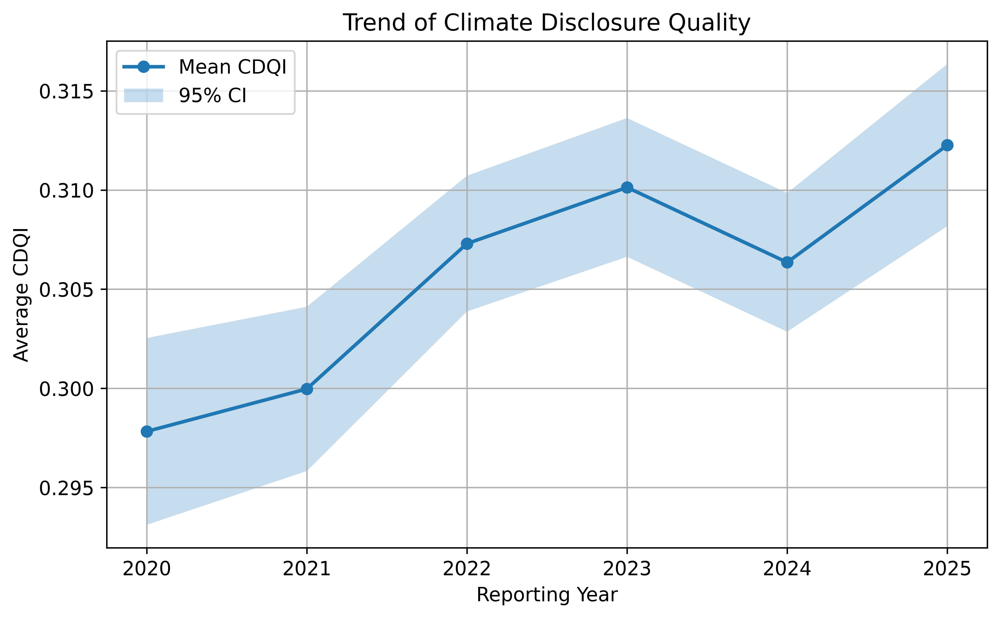

In [ ]:
from scipy.stats import sem

trend = (
    report_df
    .groupby("year")
    .agg(
        mean_CDQI=("CDQI","mean"),
        sd=("CDQI","std"),
        n=("CDQI","count")
    )
    .reset_index()
)

trend["ci95"] = 1.96 * trend["sd"] / np.sqrt(trend["n"])

plt.figure(figsize=(8,5))

plt.plot(
    trend["year"],
    trend["mean_CDQI"],
    marker="o",
    linewidth=2,
    label="Mean CDQI"
)

plt.fill_between(
    trend["year"],
    trend["mean_CDQI"]-trend["ci95"],
    trend["mean_CDQI"]+trend["ci95"],
    alpha=0.25,
    label="95% CI"
)

plt.xlabel("Reporting Year")
plt.ylabel("Average CDQI")
plt.title("Trend of Climate Disclosure Quality")
plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/figure_cdqi_trend.png",
    dpi=300
)

plt.show()

<Figure size 5400x3000 with 0 Axes>

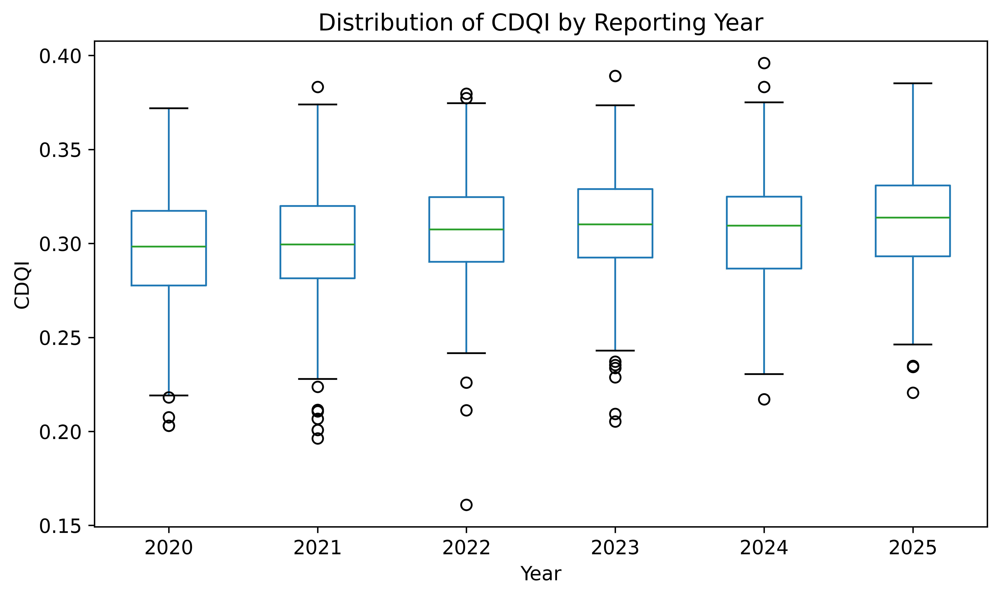

In [ ]:
plt.figure(figsize=(9,5))

report_df.boxplot(
    column="CDQI",
    by="year",
    grid=False
)

plt.title("Distribution of CDQI by Reporting Year")
plt.suptitle("")

plt.xlabel("Year")
plt.ylabel("CDQI")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/figure_boxplot_cdqi.png",
    dpi=300
)

plt.show()

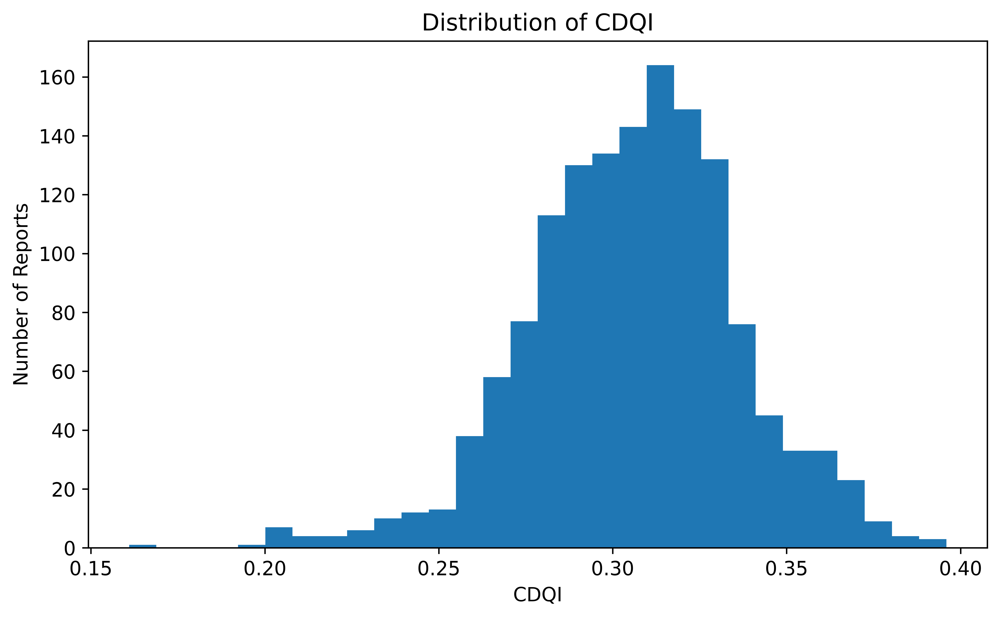

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    report_df["CDQI"],
    bins=30
)

plt.xlabel("CDQI")
plt.ylabel("Number of Reports")
plt.title("Distribution of CDQI")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/figure_histogram_cdqi.png",
    dpi=300
)

plt.show()

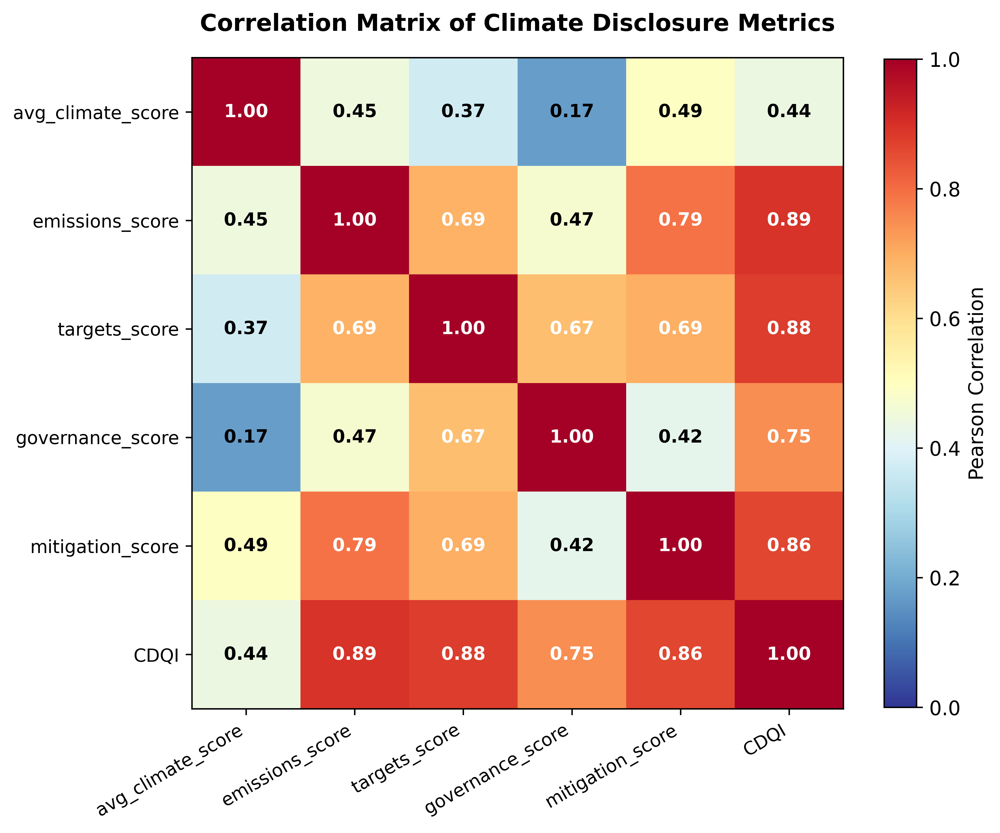

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Compute correlation matrix
corr = report_df[
    [
        "avg_climate_score",
        "emissions_score",
        "targets_score",
        "governance_score",
        "mitigation_score",
        "CDQI"
    ]
].corr()

fig, ax = plt.subplots(figsize=(8, 7))

# Better colormap
im = ax.imshow(
    corr.values,
    cmap="RdYlBu_r",      # blue → yellow → red
    vmin=0,
    vmax=1
)

# Tick labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, fontsize=10, rotation=30, ha="right")
ax.set_yticklabels(corr.columns, fontsize=10)

# Dynamic text color for readability
for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]

        text_color = "white" if value > 0.65 else "black"

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=text_color
        )

# Colorbar
cbar = plt.colorbar(im, shrink=0.85)
cbar.set_label("Pearson Correlation", fontsize=11)

plt.title(
    "Correlation Matrix of Climate Disclosure Metrics",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/figure_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

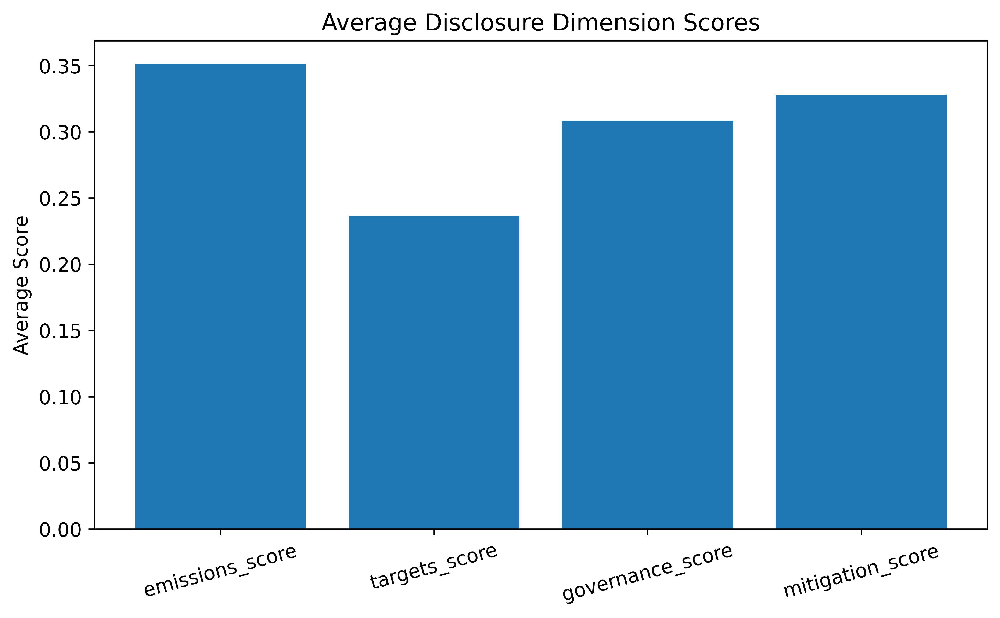

In [ ]:
dimension_means = report_df[
    [
        "emissions_score",
        "targets_score",
        "governance_score",
        "mitigation_score"
    ]
].mean()

plt.figure(figsize=(8,5))

plt.bar(
    dimension_means.index,
    dimension_means.values
)

plt.ylabel("Average Score")

plt.title("Average Disclosure Dimension Scores")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/figure_dimension_scores.png",
    dpi=300
)

plt.show()

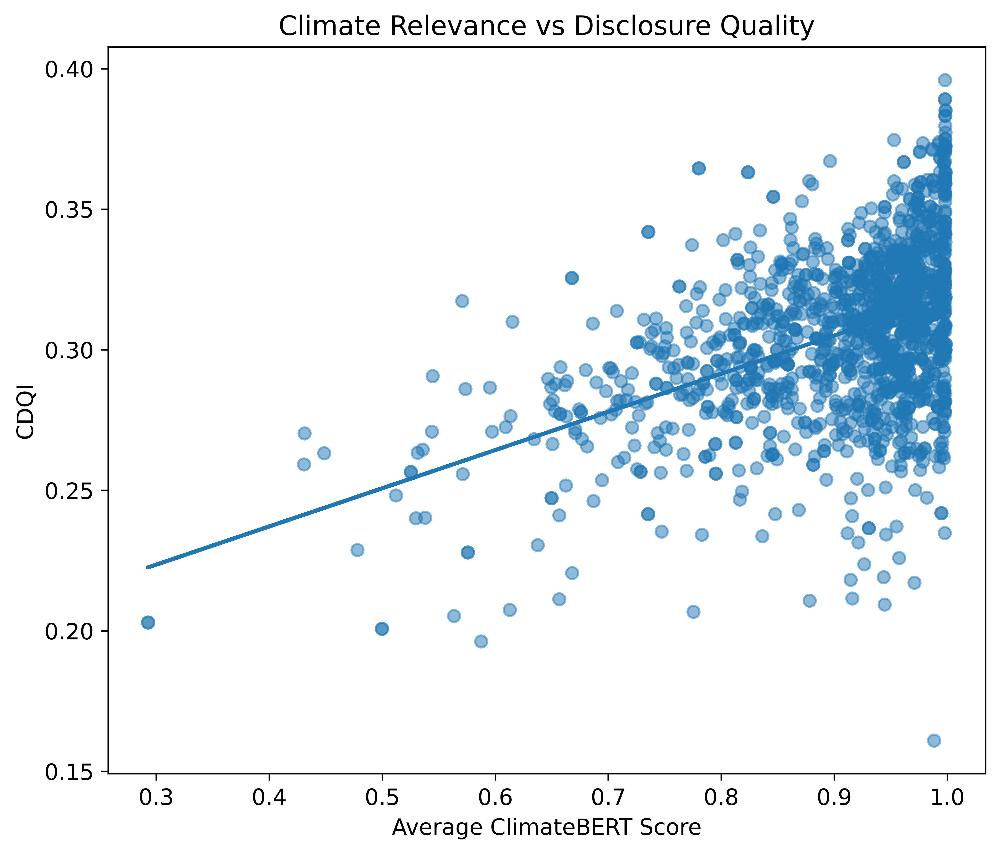

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    report_df["avg_climate_score"],
    report_df["CDQI"],
    alpha=0.5
)

z = np.polyfit(
    report_df["avg_climate_score"],
    report_df["CDQI"],
    1
)

p = np.poly1d(z)

plt.plot(
    report_df["avg_climate_score"],
    p(report_df["avg_climate_score"]),
    linewidth=2
)

plt.xlabel("Average ClimateBERT Score")

plt.ylabel("CDQI")

plt.title("Climate Relevance vs Disclosure Quality")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/figure_scatter.png",
    dpi=300
)

plt.show()

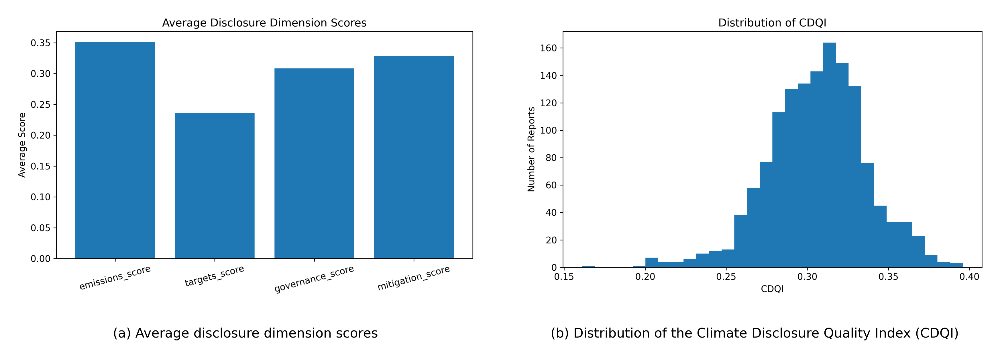

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the two figures
img1 = Image.open('/content/drive/MyDrive/figure_dimension_scores.png')   # Figure (a)
img2 = Image.open('/content/drive/MyDrive/figure_histogram_cdqi.png')     # Figure (b)

# Create a multi-panel figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Left panel
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].text(
    0.5, -0.08,
    '(a) Average disclosure dimension scores',
    ha='center',
    va='top',
    fontsize=11,
    transform=axes[0].transAxes
)

# Right panel
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].text(
    0.5, -0.08,
    '(b) Distribution of the Climate Disclosure Quality Index (CDQI)',
    ha='center',
    va='top',
    fontsize=11,
    transform=axes[1].transAxes
)

plt.tight_layout()

# Save for IEEE paper
plt.savefig(
    '/content/Figure_Multipanel.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

/tmp/ipykernel_4368/2171915287.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


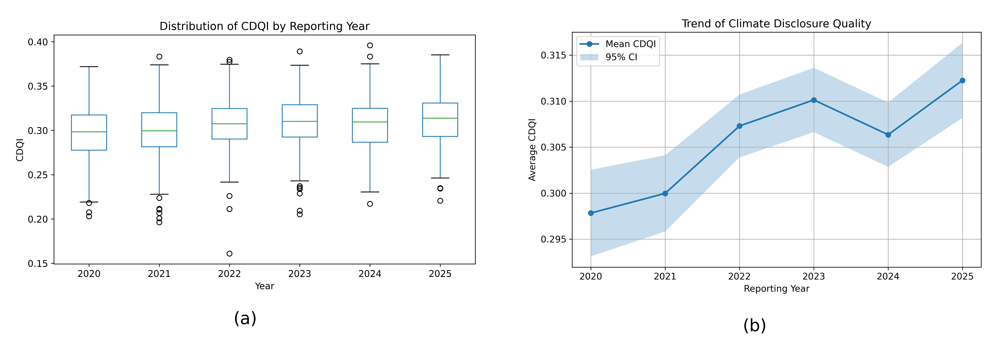

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# ==============================
# Load the two figures
# ==============================
img1 = Image.open("/content/figure_boxplot_cdqi.png")               # Trend plot
img2 = Image.open("/content/drive/MyDrive/figure_cdqi_trend.png").  # Boxplot

# ==============================
# Create multipanel figure
# ==============================
fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5,5.6),
    dpi=600,
    gridspec_kw={'wspace':0.08}
)

# Panel (a)
axes[0].imshow(img1)
axes[0].axis("off")
axes[0].text(
    0.5,
    -0.05,
    "(a)",
    ha="center",
    va="top",
    fontsize=13,
    transform=axes[0].transAxes
)

# Panel (b)
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].text(
    0.5,
    -0.05,
    "(b)",
    ha="center",
    va="top",
    fontsize=13,
    transform=axes[1].transAxes
)

plt.tight_layout()

# ==============================
# Save publication-quality image
# ==============================
plt.savefig(
    "/content/Figure_Trend_Boxplot_Multipanel.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

plt.show()

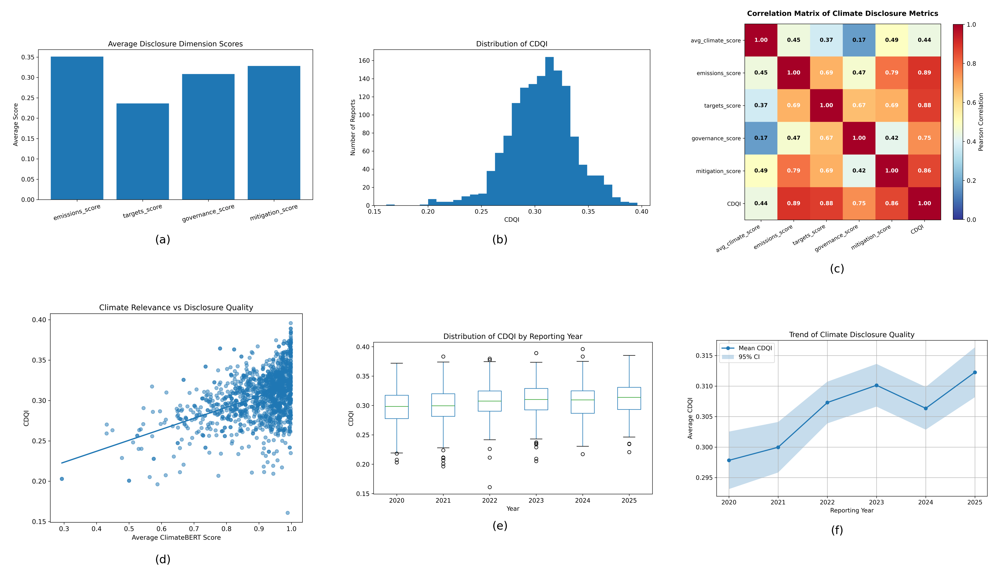

Saved: /content/All_Climate_Disclosure_Figures_Multipanel.png


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# ============================================================
# LOAD THE SIX INDIVIDUAL PANELS
# ============================================================

# Fig. 1(a)
fig1a = Image.open(
    "/content/drive/MyDrive/figure_dimension_scores.png"
)

# Fig. 1(b)
fig1b = Image.open(
    "/content/drive/MyDrive/figure_histogram_cdqi.png"
)

# Fig. 2
fig2 = Image.open(
    "/content/drive/MyDrive/figure_heatmap.png"
)

# Fig. 3
fig3 = Image.open(
    "/content/drive/MyDrive/figure_scatter.png"
)

# Fig. 4(a)
fig4a = Image.open(
    "/content/figure_boxplot_cdqi.png"
)

# Fig. 4(b)
fig4b = Image.open(
    "/content/drive/MyDrive/figure_cdqi_trend.png"
)

# ============================================================
# CREATE 3 × 2 MULTI-PANEL FIGURE
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8.5),
    dpi=300
)

# Small horizontal/vertical spacing
plt.subplots_adjust(
    left=0.015,
    right=0.985,
    top=0.98,
    bottom=0.04,
    wspace=0.08,
    hspace=0.16
)


# ============================================================
# PANEL DATA
# ============================================================

panels = [
    (fig1a, "(a)"),
    (fig1b, "(b)"),
    (fig2,  "(c)"),
    (fig3,  "(d)"),
    (fig4a, "(e)"),
    (fig4b, "(f)")
]


# ============================================================
# INSERT IMAGES
# ============================================================

for ax, (img, label) in zip(axes.flat, panels):

    ax.imshow(img)

    # Remove axes completely
    ax.axis("off")

    # Panel label
    ax.text(
        0.5,
        -0.025,
        label,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="normal",
        transform=ax.transAxes
    )


# ============================================================
# SAVE HIGH-RESOLUTION VERSION
# ============================================================

output_path = "/content/All_Climate_Disclosure_Figures_Multipanel.png"

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

print("Saved:", output_path)

In [ ]:
print("Climate-relevant chunks :", len(df))

print("Unique companies        :", df["company"].nunique())
print("Reporting years         :", sorted(df["year"].unique()))

Climate-relevant chunks : 162096


KeyError: 'company'

In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA Available: True
Tesla T4


In [ ]:
!pip -q install realesrgan
!pip -q install torch torchvision
!pip -q install pillow matplotlib
from google.colab import files

uploaded = files.upload()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 8.8 MB/s eta 0:00:00


Saving fig_AGU.png to fig_AGU (1).png


In [ ]:
!pip -q install opencv-python pillow matplotlib

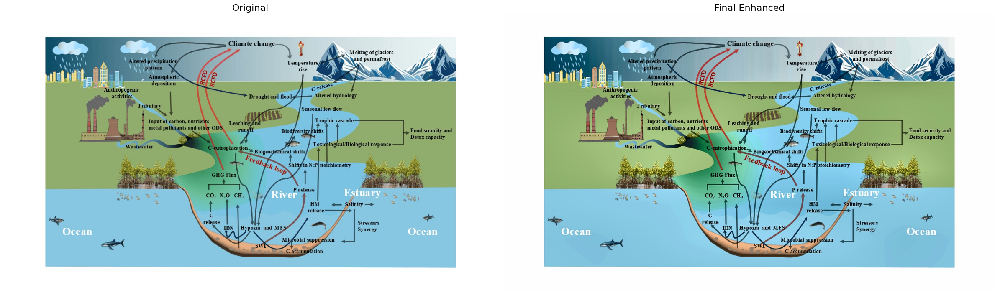

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Read Original Image
# =====================================================

img = cv2.imread("fig_AGU.png")

# =====================================================
# 4× Upscale (Best for scientific figures)
# =====================================================

scale = 4

img = cv2.resize(
    img,
    None,
    fx=scale,
    fy=scale,
    interpolation=cv2.INTER_LANCZOS4
)

# =====================================================
# Mild Non-local Means Denoising
# =====================================================

img = cv2.fastNlMeansDenoisingColored(
    img,
    None,
    h=2,
    hColor=2,
    templateWindowSize=7,
    searchWindowSize=21
)

# =====================================================
# CLAHE (Local Contrast Enhancement)
# =====================================================

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.2,
    tileGridSize=(8,8)
)

l = clahe.apply(l)

lab = cv2.merge((l,a,b))

img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# =====================================================
# Mild Gamma Correction
# =====================================================

gamma = 1.05

table = np.array([
    ((i/255.0)**(1/gamma))*255
    for i in np.arange(256)
]).astype("uint8")

img = cv2.LUT(img, table)

# =====================================================
# Slight Saturation Increase
# =====================================================

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h,s,v = cv2.split(hsv)

s = np.clip(s*1.08,0,255).astype(np.uint8)

img = cv2.cvtColor(
    cv2.merge((h,s,v)),
    cv2.COLOR_HSV2BGR
)

# =====================================================
# Edge-preserving Bilateral Filter
# =====================================================

img = cv2.bilateralFilter(
    img,
    d=7,
    sigmaColor=40,
    sigmaSpace=40
)

# =====================================================
# Moderate Unsharp Mask
# =====================================================

blur = cv2.GaussianBlur(
    img,
    (0,0),
    sigmaX=1.2
)

img = cv2.addWeighted(
    img,
    1.6,
    blur,
    -0.6,
    0
)

# =====================================================
# Gentle Sharpening
# =====================================================

kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

img = cv2.filter2D(
    img,
    -1,
    kernel
)

# =====================================================
# Save (Lossless PNG)
# =====================================================

cv2.imwrite(
    "fig_AGU_final.png",
    img,
    [cv2.IMWRITE_PNG_COMPRESSION,0]
)

# =====================================================
# Show Before / After
# =====================================================

original = cv2.cvtColor(
    cv2.imread("fig_AGU.png"),
    cv2.COLOR_BGR2RGB
)

enhanced = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(24,10))

plt.subplot(121)
plt.imshow(original)
plt.title("Original",fontsize=16)
plt.axis("off")

plt.subplot(122)
plt.imshow(enhanced)
plt.title("Final Enhanced",fontsize=16)
plt.axis("off")

plt.tight_layout()

plt.show()

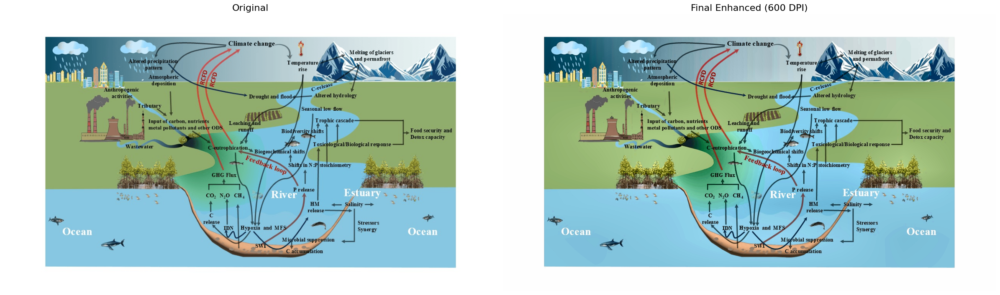

Saved as: fig_AGU_final_600dpi.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =====================================================
# Read Original Image
# =====================================================

img = cv2.imread("fig_AGU.png")

# =====================================================
# 4× Upscale (Best for scientific figures)
# =====================================================

scale = 4

img = cv2.resize(
    img,
    None,
    fx=scale,
    fy=scale,
    interpolation=cv2.INTER_LANCZOS4
)

# =====================================================
# Mild Non-local Means Denoising
# =====================================================

img = cv2.fastNlMeansDenoisingColored(
    img,
    None,
    h=2,
    hColor=2,
    templateWindowSize=7,
    searchWindowSize=21
)

# =====================================================
# CLAHE (Local Contrast Enhancement)
# =====================================================

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.2,
    tileGridSize=(8,8)
)

l = clahe.apply(l)

lab = cv2.merge((l,a,b))

img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# =====================================================
# Mild Gamma Correction
# =====================================================

gamma = 1.05

table = np.array([
    ((i/255.0)**(1/gamma))*255
    for i in np.arange(256)
]).astype("uint8")

img = cv2.LUT(img, table)

# =====================================================
# Slight Saturation Increase
# =====================================================

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h,s,v = cv2.split(hsv)

s = np.clip(s*1.08,0,255).astype(np.uint8)

img = cv2.cvtColor(
    cv2.merge((h,s,v)),
    cv2.COLOR_HSV2BGR
)

# =====================================================
# Edge-preserving Bilateral Filter
# =====================================================

img = cv2.bilateralFilter(
    img,
    d=7,
    sigmaColor=40,
    sigmaSpace=40
)

# =====================================================
# Moderate Unsharp Mask
# =====================================================

blur = cv2.GaussianBlur(
    img,
    (0,0),
    sigmaX=1.2
)

img = cv2.addWeighted(
    img,
    1.6,
    blur,
    -0.6,
    0
)

# =====================================================
# Gentle Sharpening
# =====================================================

kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

img = cv2.filter2D(
    img,
    -1,
    kernel
)

# =====================================================
# Save Temporary PNG
# =====================================================

cv2.imwrite(
    "fig_AGU_temp.png",
    img,
    [cv2.IMWRITE_PNG_COMPRESSION,0]
)

# =====================================================
# Save Final PNG with 600 DPI metadata
# =====================================================

final_img = Image.open("fig_AGU_temp.png")

final_img.save(
    "fig_AGU_final_600dpi.png",
    dpi=(600,600),
    optimize=True
)

# =====================================================
# Display
# =====================================================

original = cv2.cvtColor(
    cv2.imread("fig_AGU.png"),
    cv2.COLOR_BGR2RGB
)

enhanced = np.array(final_img)

plt.figure(figsize=(24,10))

plt.subplot(121)
plt.imshow(original)
plt.title("Original",fontsize=16)
plt.axis("off")

plt.subplot(122)
plt.imshow(enhanced)
plt.title("Final Enhanced (600 DPI)",fontsize=16)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Saved as: fig_AGU_final_600dpi.png")

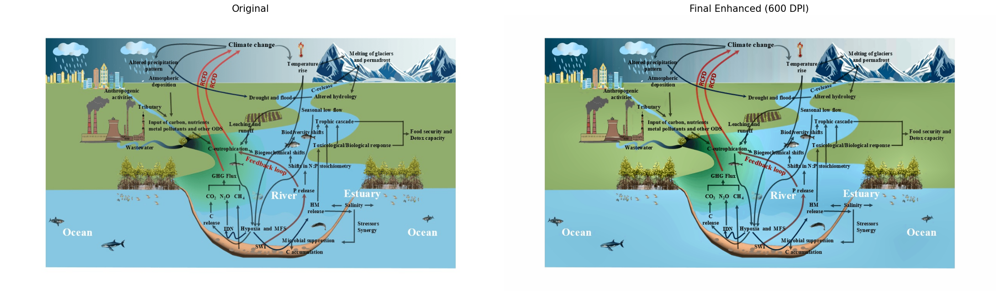

Saved as fig_AGU_final_600dpi.png


In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# =====================================================
# Read Original Image
# =====================================================

img = cv2.imread("fig_AGU.png")

# =====================================================
# 4× Lanczos Upscaling
# =====================================================

img = cv2.resize(
    img,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_LANCZOS4
)

# =====================================================
# Mild Non-local Means Denoising
# =====================================================

img = cv2.fastNlMeansDenoisingColored(
    img,
    None,
    h=2,
    hColor=2,
    templateWindowSize=7,
    searchWindowSize=21
)

# =====================================================
# LAB Color Space
# =====================================================

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

L,A,B = cv2.split(lab)

# =====================================================
# CLAHE (only luminance)
# =====================================================

clahe = cv2.createCLAHE(
    clipLimit=2.2,
    tileGridSize=(8,8)
)

L = clahe.apply(L)

# =====================================================
# Mild Gamma Correction
# =====================================================

gamma = 1.04

table = np.array([
    ((i/255.0)**(1/gamma))*255
    for i in np.arange(256)
]).astype(np.uint8)

L = cv2.LUT(L, table)

# =====================================================
# Luminance Unsharp Mask
# =====================================================

blur = cv2.GaussianBlur(
    L,
    (0,0),
    sigmaX=1.2
)

L = cv2.addWeighted(
    L,
    1.45,
    blur,
    -0.45,
    0
)

# =====================================================
# Merge LAB
# =====================================================

lab = cv2.merge((L,A,B))

img = cv2.cvtColor(
    lab,
    cv2.COLOR_LAB2BGR
)

# =====================================================
# Slight Saturation Increase
# =====================================================

hsv = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2HSV
)

H,S,V = cv2.split(hsv)

S = np.clip(
    S.astype(np.float32)*1.06,
    0,
    255
).astype(np.uint8)

img = cv2.cvtColor(
    cv2.merge((H,S,V)),
    cv2.COLOR_HSV2BGR
)

# =====================================================
# Edge-preserving Bilateral Filter
# =====================================================

img = cv2.bilateralFilter(
    img,
    d=7,
    sigmaColor=40,
    sigmaSpace=40
)

# =====================================================
# Edge Detection
# =====================================================

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

edges = cv2.Canny(
    gray,
    60,
    180
)

edges = cv2.dilate(
    edges,
    np.ones((3,3),np.uint8),
    iterations=1
)

mask = edges.astype(np.float32)/255.0
mask = cv2.GaussianBlur(mask,(7,7),0)

mask = mask[:,:,None]

# =====================================================
# Edge-aware Sharpening
# =====================================================

kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
],dtype=np.float32)

sharp = cv2.filter2D(
    img,
    -1,
    kernel
)

img = (
    sharp*mask +
    img*(1-mask)
).astype(np.uint8)

# =====================================================
# Save Temporary PNG
# =====================================================

cv2.imwrite(
    "temp.png",
    img,
    [cv2.IMWRITE_PNG_COMPRESSION,0]
)

# =====================================================
# Save Final PNG (600 DPI)
# =====================================================

Image.open("temp.png").save(
    "fig_AGU_final_600dpi.png",
    dpi=(600,600),
    optimize=True
)

# =====================================================
# Display
# =====================================================

original = cv2.cvtColor(
    cv2.imread("fig_AGU.png"),
    cv2.COLOR_BGR2RGB
)

final = np.array(
    Image.open("fig_AGU_final_600dpi.png")
)

plt.figure(figsize=(22,10))

plt.subplot(121)
plt.imshow(original)
plt.title("Original",fontsize=15)
plt.axis("off")

plt.subplot(122)
plt.imshow(final)
plt.title("Final Enhanced (600 DPI)",fontsize=15)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Saved as fig_AGU_final_600dpi.png")

In [ ]:
"""
enhance_figure_journal_safe.py — Colab/Jupyter-friendly version
------------------------------------------------------------------
Conservative upscaling for a figure going into a journal submission.

Deliberately does NOT change color, contrast, or invent detail:
    - no saturation boost, no white balance shift
    - no CLAHE, no gamma correction
    - no AI/generative super-resolution

Just: high-quality Lanczos upscale, optional mild denoise, optional
edge-limited sharpen (all off by default), saved as PNG + TIFF at your
chosen DPI.

Edit the CONFIG block below, then run the cell.
"""

import cv2
import numpy as np
from PIL import Image

# =====================================================
# CONFIG -- edit these, then run the cell
# =====================================================
INPUT_PATH        = "fig_AGU.png"   # path to your source image (upload it first)
OUTPUT_PREFIX     = None            # None -> auto: "<input>_journal"
SCALE             = 4.0             # upscale factor
DPI               = 600             # DPI metadata tag for output files
DENOISE           = False           # True to remove genuine compression noise (mild)
MILD_SHARPEN      = False           # True for light edge-limited sharpen
TIFF_COMPRESSION  = "lzw"           # "lzw" (lossless) or "none" (uncompressed)
# =====================================================


def load_as_rgb(path: str) -> np.ndarray:
    """Load via PIL so indexed/palette PNGs are expanded to true RGB."""
    pil_img = Image.open(path).convert("RGB")
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)


def mild_denoise(img: np.ndarray) -> np.ndarray:
    """Very light — removes genuine compression noise only, not detail."""
    return cv2.fastNlMeansDenoisingColored(
        img, None, h=2, hColor=2, templateWindowSize=7, searchWindowSize=21
    )


def upscale(img: np.ndarray, scale: float) -> np.ndarray:
    """Lanczos: deterministic, non-generative -- does not invent content."""
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_LANCZOS4)


def mild_edge_sharpen(img: np.ndarray, amount: float = 0.35) -> np.ndarray:
    """Small, edge-limited sharpen -- doesn't touch flat color regions,
    so it can't alter represented data or shift colors."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 60, 160)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
    mask = cv2.GaussianBlur(edges.astype(np.float32) / 255.0, (5, 5), 0)[:, :, None]

    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=1.0)
    unsharp = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)

    return (unsharp * mask + img * (1 - mask)).astype(np.uint8)


def run(input_path, output_prefix, scale, dpi, denoise, mild_sharpen, tiff_compression):
    prefix = output_prefix or input_path.rsplit(".", 1)[0] + "_journal"

    img = load_as_rgb(input_path)
    print(f"Loaded {input_path}: {img.shape[1]}x{img.shape[0]}")

    if denoise:
        img = mild_denoise(img)
        print("Applied mild denoise")

    img = upscale(img, scale)
    print(f"Upscaled to: {img.shape[1]}x{img.shape[0]} ({scale}x, Lanczos)")

    if mild_sharpen:
        img = mild_edge_sharpen(img)
        print("Applied mild edge-limited sharpen")

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_out = Image.fromarray(rgb)

    png_path = f"{prefix}.png"
    pil_out.save(png_path, dpi=(dpi, dpi), optimize=True)
    print(f"Saved -> {png_path}")

    tiff_path = f"{prefix}.tiff"
    compression = None if tiff_compression == "none" else "tiff_lzw"
    pil_out.save(tiff_path, dpi=(dpi, dpi), compression=compression)
    print(f"Saved -> {tiff_path}")

    return png_path, tiff_path


png_path, tiff_path = run(
    INPUT_PATH, OUTPUT_PREFIX, SCALE, DPI, DENOISE, MILD_SHARPEN, TIFF_COMPRESSION
)

Loaded fig_AGU.png: 1280x720
Upscaled to: 5120x2880 (4.0x, Lanczos)
Saved -> fig_AGU_journal.png
Saved -> fig_AGU_journal.tiff


In [ ]:
"""
journal_safe_figure_4x.py
--------------------------------------------------------
Nature / Science / AGU safe figure preparation

Operations:
✓ Remove surrounding white margins
✓ Preserve colours exactly
✓ Preserve contrast exactly
✓ Preserve brightness exactly
✓ No AI enhancement
✓ No sharpening
✓ No denoising
✓ No CLAHE
✓ No histogram equalization
✓ Lanczos interpolation only
✓ Save as 600 dpi PNG
"""

import cv2
import numpy as np
from PIL import Image

# ==========================================================
# CONFIG
# ==========================================================

INPUT_PATH = "/content/fig_AGU.png"
OUTPUT_PATH = "/content/fig2.png"

UPSCALE = 4.0

DPI = 600

WHITE_THRESHOLD = 250

# ==========================================================


def crop_white_border(img, threshold=250):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mask = gray < threshold

    coords = np.argwhere(mask)

    if coords.size == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img[y0:y1, x0:x1]


# ----------------------------------------------------------

img = cv2.imread(INPUT_PATH)

if img is None:
    raise FileNotFoundError(INPUT_PATH)

print(f"Original size : {img.shape[1]} x {img.shape[0]}")

img = crop_white_border(img, WHITE_THRESHOLD)

print(f"Cropped size  : {img.shape[1]} x {img.shape[0]}")

new_width = int(img.shape[1] * UPSCALE)
new_height = int(img.shape[0] * UPSCALE)

img = cv2.resize(
    img,
    (new_width, new_height),
    interpolation=cv2.INTER_LANCZOS4
)

print(f"Upscaled size : {img.shape[1]} x {img.shape[0]}")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Image.fromarray(rgb).save(
    OUTPUT_PATH,
    dpi=(DPI, DPI),
    compress_level=0
)

print()
print("Done.")
print("Saved:", OUTPUT_PATH)
print("600 DPI PNG")

Original size : 1280 x 720
Cropped size  : 1068 x 600
Upscaled size : 4272 x 2400

Done.
Saved: /content/fig2.png
600 DPI PNG


In [ ]:
"""
compare_figures.py
----------------------------------------------------------
Compare Original vs Enhanced figure

Outputs:

1. Side-by-side
2. Overlay (50%)
3. Absolute Difference
4. Edge Difference
5. 4x Zoom Comparison

No metrics yet.
"""

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# ============================================================
# CONFIG
# ============================================================

ORIGINAL = "/content/fig_AGU.png"

ENHANCED = "/content/fig2.png"

OUTPUT_DIR = "comparison_output"

ZOOM_SIZE = 600          # crop size (pixels)

# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)


def load_rgb(path):
    img = cv2.imread(path)

    if img is None:
        raise FileNotFoundError(path)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


orig = load_rgb(ORIGINAL)
enh = load_rgb(ENHANCED)

print("Original :", orig.shape)
print("Enhanced :", enh.shape)

# ------------------------------------------------------------
# Resize enhanced if dimensions differ
# ------------------------------------------------------------

if orig.shape != enh.shape:

    print("Resizing enhanced image to match original...")

    enh = cv2.resize(
        enh,
        (orig.shape[1], orig.shape[0]),
        interpolation=cv2.INTER_AREA,
    )

# ============================================================
# 1. Side by Side
# ============================================================

fig = plt.figure(figsize=(16,8))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.axis("off")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(enh)
plt.axis("off")
plt.title("Enhanced")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR,"01_side_by_side.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Saved side-by-side")

# ============================================================
# 2. Overlay
# ============================================================

overlay = cv2.addWeighted(orig,0.5,enh,0.5,0)

Image.fromarray(overlay).save(
    os.path.join(OUTPUT_DIR,"02_overlay.png")
)

print("Saved overlay")

# ============================================================
# 3. Absolute Difference
# ============================================================

diff = cv2.absdiff(orig,enh)

Image.fromarray(diff).save(
    os.path.join(OUTPUT_DIR,"03_absolute_difference.png")
)

print("Saved difference image")

# ============================================================
# 4. Edge Comparison
# ============================================================

gray1 = cv2.cvtColor(orig,cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(enh,cv2.COLOR_RGB2GRAY)

edge1 = cv2.Canny(gray1,75,200)
edge2 = cv2.Canny(gray2,75,200)

edge_stack = np.hstack((edge1,edge2))

Image.fromarray(edge_stack).save(
    os.path.join(OUTPUT_DIR,"04_edge_comparison.png")
)

print("Saved edge comparison")

# ============================================================
# 5. Edge Difference
# ============================================================

edge_diff = cv2.absdiff(edge1,edge2)

Image.fromarray(edge_diff).save(
    os.path.join(OUTPUT_DIR,"05_edge_difference.png")
)

print("Saved edge difference")

# ============================================================
# 6. Center Zoom
# ============================================================

h,w = orig.shape[:2]

cx = w//2
cy = h//2

half = ZOOM_SIZE//2

crop1 = orig[
    max(0,cy-half):min(h,cy+half),
    max(0,cx-half):min(w,cx+half)
]

crop2 = enh[
    max(0,cy-half):min(h,cy+half),
    max(0,cx-half):min(w,cx+half)
]

fig = plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.imshow(crop1)
plt.axis("off")
plt.title("Original (Center Zoom)")

plt.subplot(1,2,2)
plt.imshow(crop2)
plt.axis("off")
plt.title("Enhanced (Center Zoom)")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR,"06_center_zoom.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Saved zoom comparison")

print("\nDone.")
print("Output folder:",OUTPUT_DIR)

Original : (720, 1280, 3)
Enhanced : (2400, 4272, 3)
Resizing enhanced image to match original...
Saved side-by-side
Saved overlay
Saved difference image
Saved edge comparison
Saved edge difference
Saved zoom comparison

Done.
Output folder: comparison_output


In [ ]:
# =============================================================================
# Step 7 – Quantitative Validation (self‑contained)
# =============================================================================

import cv2
import numpy as np
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from skimage import feature
from scipy.stats import entropy
import imagehash
import pandas as pd
import os
import json

# ------------------------------------------------------------
# 1. Load the images from disk (saved in previous steps)
# ------------------------------------------------------------
# Load the cropped original (small), Lanczos 4x, and Real‑ESRGAN 4x
original_img = Image.open('fig_AGU.png').convert('RGB')
lanczos_img = Image.open('NPJ Figure.png').convert('RGB')
esrgan_img = Image.open('fig2.png').convert('RGB')

# Convert to numpy arrays (RGB)
original_np = np.array(original_img)
lanczos_np = np.array(lanczos_img)
esrgan_np = np.array(esrgan_img)

# ------------------------------------------------------------
# 2. Downsample the upscaled images back to original size
# ------------------------------------------------------------
orig_size = original_img.size  # (width, height)
lanczos_down = lanczos_img.resize(orig_size, Image.Resampling.LANCZOS)
esrgan_down = esrgan_img.resize(orig_size, Image.Resampling.LANCZOS)
lanczos_down_np = np.array(lanczos_down)
esrgan_down_np = np.array(esrgan_down)

# ------------------------------------------------------------
# 3. Convert to float [0,1] and create grayscale versions
# ------------------------------------------------------------
def to_float(img):
    return img.astype(np.float32) / 255.0

orig_f = to_float(original_np)
lanc_down_f = to_float(lanczos_down_np)
esr_down_f = to_float(esrgan_down_np)
lanc_f = to_float(lanczos_np)
esr_f = to_float(esrgan_np)

orig_gray = cv2.cvtColor(original_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
lanc_down_gray = cv2.cvtColor(lanczos_down_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
esr_down_gray = cv2.cvtColor(esrgan_down_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
lanc_gray = cv2.cvtColor(lanczos_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
esr_gray = cv2.cvtColor(esrgan_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# ------------------------------------------------------------
# 4. Define the metrics function
# ------------------------------------------------------------
def compute_metrics(im1, im2, im1_gray, im2_gray, name1, name2):
    metrics = {}
    # SSIM (on grayscale)
    metrics['SSIM'] = ssim(im1_gray, im2_gray, data_range=1.0)
    # MSE & PSNR (on RGB)
    mse = np.mean((im1 - im2) ** 2)
    metrics['MSE'] = mse
    metrics['RMSE'] = np.sqrt(mse)
    metrics['PSNR'] = 10 * np.log10(1.0 / (mse + 1e-10))
    # Normalized Cross Correlation (NCC)
    metrics['NCC'] = np.corrcoef(im1_gray.flatten(), im2_gray.flatten())[0, 1]
    # Histogram Correlation (average over channels)
    hist_corr = []
    for c in range(3):
        h1 = np.histogram(im1[:, :, c], bins=256, range=(0, 1))[0] / im1[:, :, c].size
        h2 = np.histogram(im2[:, :, c], bins=256, range=(0, 1))[0] / im2[:, :, c].size
        hist_corr.append(np.corrcoef(h1, h2)[0, 1])
    metrics['Histogram Correlation'] = np.mean(hist_corr)
    # Histogram Intersection (average over channels)
    hist_inter = []
    for c in range(3):
        h1 = np.histogram(im1[:, :, c], bins=256, range=(0, 1))[0]
        h2 = np.histogram(im2[:, :, c], bins=256, range=(0, 1))[0]
        inter = np.sum(np.minimum(h1, h2)) / np.sum(h1)
        hist_inter.append(inter)
    metrics['Histogram Intersection'] = np.mean(hist_inter)
    # Bhattacharyya Distance (grayscale)
    h1 = np.histogram(im1_gray, bins=256, range=(0, 1))[0] / im1_gray.size
    h2 = np.histogram(im2_gray, bins=256, range=(0, 1))[0] / im2_gray.size
    bc = np.sum(np.sqrt(h1 * h2 + 1e-10))
    metrics['Bhattacharyya Distance'] = -np.log(bc) if bc > 0 else float('inf')
    # Edge Similarity and Edge Difference %
    edges1 = feature.canny(im1_gray, sigma=1.0)
    edges2 = feature.canny(im2_gray, sigma=1.0)
    intersection = np.logical_and(edges1, edges2).sum()
    union = np.logical_or(edges1, edges2).sum()
    metrics['Edge Similarity'] = intersection / union if union > 0 else 0
    diff_edges = np.logical_xor(edges1, edges2)
    metrics['Edge Difference %'] = diff_edges.sum() / edges1.size * 100
    # Hash distances (using imagehash)
    pil1 = Image.fromarray((im1 * 255).astype(np.uint8))
    pil2 = Image.fromarray((im2 * 255).astype(np.uint8))
    metrics['Perceptual Hash Distance'] = imagehash.phash(pil1) - imagehash.phash(pil2)
    metrics['Average Hash Distance'] = imagehash.average_hash(pil1) - imagehash.average_hash(pil2)
    metrics['Difference Hash Distance'] = imagehash.dhash(pil1) - imagehash.dhash(pil2)
    metrics['Wavelet Hash Distance'] = imagehash.whash(pil1) - imagehash.whash(pil2)
    # Color Histogram Distance (Chi2 on flattened 32‑bin histograms)
    h1_flat = np.concatenate([np.histogram(im1[:, :, c], bins=32, range=(0, 1))[0] for c in range(3)])
    h2_flat = np.concatenate([np.histogram(im2[:, :, c], bins=32, range=(0, 1))[0] for c in range(3)])
    h1_flat = h1_flat / (np.sum(h1_flat) + 1e-10)
    h2_flat = h2_flat / (np.sum(h2_flat) + 1e-10)
    metrics['Color Histogram Distance (Chi2)'] = np.sum(
        (h1_flat - h2_flat) ** 2 / (h1_flat + h2_flat + 1e-10)
    )
    # Laplacian Variance (sharpness) difference
    lap_var1 = cv2.Laplacian(im1_gray, cv2.CV_64F).var()
    lap_var2 = cv2.Laplacian(im2_gray, cv2.CV_64F).var()
    metrics['Laplacian Variance Difference'] = lap_var1 - lap_var2
    # Gradient Magnitude Difference (mean absolute difference)
    gx1, gy1 = np.gradient(im1_gray)
    gm1 = np.sqrt(gx1 ** 2 + gy1 ** 2)
    gx2, gy2 = np.gradient(im2_gray)
    gm2 = np.sqrt(gx2 ** 2 + gy2 ** 2)
    metrics['Gradient Magnitude Difference'] = np.mean(np.abs(gm1 - gm2))
    # Entropy difference (grayscale)
    h1 = np.histogram(im1_gray, bins=256, range=(0, 1))[0] / im1_gray.size
    h2 = np.histogram(im2_gray, bins=256, range=(0, 1))[0] / im2_gray.size
    metrics['Entropy Difference'] = entropy(h1 + 1e-10) - entropy(h2 + 1e-10)
    # Store image labels
    metrics['Image1'] = name1
    metrics['Image2'] = name2
    return metrics

# ------------------------------------------------------------
# 5. Compute metrics for three pairs
# ------------------------------------------------------------
pairs = [
    (orig_f, lanc_down_f, orig_gray, lanc_down_gray, 'Original', 'Lanczos (downsampled)'),
    (orig_f, esr_down_f, orig_gray, esr_down_gray, 'Original', 'RealESRGAN (downsampled)'),
    (lanc_f, esr_f, lanc_gray, esr_gray, 'Lanczos (4x)', 'RealESRGAN (4x)')
]

all_metrics = []
for im1, im2, g1, g2, name1, name2 in pairs:
    all_metrics.append(compute_metrics(im1, im2, g1, g2, name1, name2))

df_metrics = pd.DataFrame(all_metrics)
cols = ['Image1', 'Image2'] + [c for c in df_metrics.columns if c not in ['Image1', 'Image2']]
df_metrics = df_metrics[cols]

# ------------------------------------------------------------
# 6. Print metrics nicely
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("QUANTITATIVE METRICS")
print("=" * 70)
print(df_metrics.to_string(index=False))
print("=" * 70)

# Save to CSV/JSON
os.makedirs('results/metrics', exist_ok=True)
df_metrics.to_csv('results/metrics/comparison_metrics.csv', index=False)
df_metrics.to_json('results/metrics/metrics.json', orient='records')

# =============================================================================
# Step 8 – OCR Validation (self‑contained)
# =============================================================================

import easyocr
import difflib

# Initialize EasyOCR reader (English)
reader = easyocr.Reader(['en'])

def extract_text_ocr(img_rgb):
    """Extract text, confidence, and bounding boxes."""
    results = reader.readtext(np.array(img_rgb))
    texts, confidences, bboxes = [], [], []
    for (bbox, text, conf) in results:
        texts.append(text)
        confidences.append(conf)
        bboxes.append(bbox)
    return texts, confidences, bboxes

# Use the loaded PIL images (original_img, lanczos_img, esrgan_img)
ocr_original = extract_text_ocr(original_img)
ocr_lanczos = extract_text_ocr(lanczos_img)
ocr_esrgan = extract_text_ocr(esrgan_img)

# Print extraction results
print("\n" + "=" * 70)
print("OCR EXTRACTION")
print("=" * 70)
for name, ocr_data in [('Original', ocr_original), ('Lanczos', ocr_lanczos), ('RealESRGAN', ocr_esrgan)]:
    texts, confs, _ = ocr_data
    print(f"\n{name}:")
    for t, c in zip(texts, confs):
        print(f"  '{t}' (conf: {c:.2f})")
print("=" * 70)

# Function to compare two text lists using difflib
def compare_text_lists(list1, list2, name1, name2):
    text1 = ' '.join(list1)
    text2 = ' '.join(list2)
    diff = difflib.ndiff(text1.split(), text2.split())
    added = [w[2:] for w in diff if w.startswith('+ ')]
    removed = [w[2:] for w in diff if w.startswith('- ')]
    # Levenshtein distance for CER and WER
    def levenshtein(s1, s2):
        if len(s1) < len(s2):
            return levenshtein(s2, s1)
        if len(s2) == 0:
            return len(s1)
        previous_row = range(len(s2) + 1)
        for i, c1 in enumerate(s1):
            current_row = [i + 1]
            for j, c2 in enumerate(s2):
                insertions = previous_row[j + 1] + 1
                deletions = current_row[j] + 1
                substitutions = previous_row[j] + (c1 != c2)
                current_row.append(min(insertions, deletions, substitutions))
            previous_row = current_row
        return previous_row[-1]
    cer = levenshtein(text1, text2) / max(len(text1), 1)
    wer = levenshtein(text1.split(), text2.split()) / max(len(text1.split()), 1)
    return {'Added': added, 'Removed': removed, 'CER': cer, 'WER': wer}

# Compare all pairs
ocr_pairs = [
    (ocr_original[0], ocr_lanczos[0], 'Original', 'Lanczos'),
    (ocr_original[0], ocr_esrgan[0], 'Original', 'RealESRGAN'),
    (ocr_lanczos[0], ocr_esrgan[0], 'Lanczos', 'RealESRGAN')
]

print("\nOCR DIFFERENCES (insertions, deletions, substitutions):")
for list1, list2, n1, n2 in ocr_pairs:
    result = compare_text_lists(list1, list2, n1, n2)
    print(f"\n{n1} vs {n2}:")
    print(f"  Added words: {result['Added']}")
    print(f"  Removed words: {result['Removed']}")
    print(f"  Character Error Rate (CER): {result['CER']:.3f}")
    print(f"  Word Error Rate (WER): {result['WER']:.3f}")

# Save OCR results to JSON
ocr_data = {
    'original': {'texts': ocr_original[0], 'confidences': ocr_original[1]},
    'lanczos': {'texts': ocr_lanczos[0], 'confidences': ocr_lanczos[1]},
    'realesrgan': {'texts': ocr_esrgan[0], 'confidences': ocr_esrgan[1]}
}
with open('results/metrics/ocr_output.json', 'w') as f:
    json.dump(ocr_data, f, indent=2)

print("\n✅ Step 7 and Step 8 completed. Metrics saved to 'results/metrics/'.")

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/filter.simd.hpp:3250: error: (-213:The function/feature is not implemented) Unsupported combination of source format (=5), and destination format (=6) in function 'getLinearFilter'
